In [57]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.compose import TransformedTargetRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import LearningCurveDisplay
from xgboost import plot_importance


df = pd.read_csv(r"C:\Users\talon\Downloads\hour.csv\BikeSharing_Train.csv")
# df = df_orig.sample(frac=0.2, random_state=42)
# import files and load file


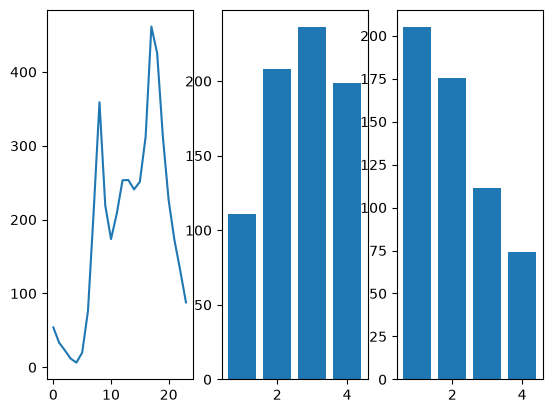

In [5]:
plt.figure()
plt.subplot(131)
plt.plot(np.arange(24), df['cnt'].groupby(df['hr']).mean())
plt.subplot(132)
plt.bar([1,2,3,4], df['cnt'].groupby(df['season']).mean())
plt.subplot(133)
plt.bar([1,2,3,4], df['cnt'].groupby(df['weathersit']).mean())
plt.show()


In [ ]:
columns_drop = ['instant', 'casual', 'registered','dteday']
X_base = df.drop(columns_drop, axis = 1)
y_base = X_base.pop('cnt')

num_pipe = Pipeline(steps = [('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
obj_pipe = Pipeline(steps = [('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])
cat_cols = ['season', 'weathersit']
num_cols = ['yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'temp', 'atemp', 'hum', 'windspeed']
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipe, num_cols),
    ('cat', obj_pipe, cat_cols)],
    remainder='drop')
baseline_model = Pipeline(steps=[('preprocessor', preprocessor),('classifier', RandomForestRegressor(n_estimators=100, random_state=42))])
baseline_CV = -1*(cross_val_score(baseline_model, X_base, y_base, cv=5, scoring='neg_mean_squared_log_error').mean())
print(baseline_CV)



In [ ]:
X_eng = X_base.copy()
def correct_hum(x):
    if(x==0):
        x = .08
    return x

X_eng['hum'] = X_eng['hum'].apply(correct_hum)

# humidity has a physically impossible value of 0. This sets that value to the min


X_eng['rush_hour'] = X_eng['hr'].isin([7,8,17,18]).astype(int)
X_eng['normal_temp'] = X_eng['temp']*41
X_eng['dew_point'] = (237.7*((17.27*X_eng['normal_temp'])/(237.7+X_eng['normal_temp'])+np.log(X_eng['hum'])))/(17.27-((17.27*X_eng['normal_temp'])/(237.7+X_eng['normal_temp'])+np.log(X_eng['hum'])))
X_eng['humidex'] = (X_eng['normal_temp'] + 0.5555*((6.1078*(10**((7.5*X_eng['dew_point'])/(237.3+X_eng['dew_point']))))-10))/41



num_cols2 = num_cols + ['rush_hour', 'humidex']

preprocessor2 = ColumnTransformer(transformers=[
    ('num', num_pipe, num_cols2),
    ('cat', obj_pipe, cat_cols)],
    remainder='drop')


model2 = Pipeline(steps=[('preprocessor', preprocessor2),('classifier', RandomForestRegressor(n_estimators=100, random_state=42))])
model3 = Pipeline(steps=[('preprocessor', preprocessor2),
                          ('model', TransformedTargetRegressor(regressor= GradientBoostingRegressor(n_estimators=100, random_state=42),func=np.log1p, inverse_func=np.expm1))])
XGBmodel = Pipeline(steps=[('preprocessor', preprocessor2),
                          ('model', TransformedTargetRegressor(regressor= XGBRegressor(n_estimators=100, random_state=42),func=np.log1p, inverse_func=np.expm1))])
model2_log = TransformedTargetRegressor(regressor=model2, func=np.log1p, inverse_func=np.expm1)



model2_CV = -1*(cross_val_score(model2, X_eng, y_base, cv=5, scoring='neg_mean_squared_log_error').mean())
model2_log_CV = -1*(cross_val_score(model2_log, X_eng, y_base, cv=5, scoring='neg_mean_squared_log_error').mean())
XGBmodel_CV = -1*(cross_val_score(XGBmodel, X_eng, y_base, cv=5, scoring='neg_mean_squared_log_error').mean())
model3_CV = -1*(cross_val_score(model3, X_eng, y_base, cv=5, scoring='neg_mean_squared_log_error').mean())

print('Forest Model CV:', model2_CV)
print('Forest Model log CV:', model2_log_CV)
print('XGB Model log CV:', XGBmodel_CV)
print('Gradient Boost Model log CV:', model3_CV)




The XGBmodel seems to be the best model, and using the log transformation minimizes CV


In [ ]:
params = {'model__regressor__n_estimators': [100, 200], 'model__regressor__max_depth': [3,6,10], 'model__regressor__gamma': [0,1,2], 'preprocessor': [preprocessor, preprocessor2]}
search = RandomizedSearchCV(estimator = XGBmodel, param_distributions = params, n_iter = 30, cv = 5, scoring = 'neg_mean_squared_log_error', random_state = 42)
search.fit(X_eng, y_base)
print(search.best_params_)
XGBmodel_tuned  = Pipeline(steps=[('preprocessor', preprocessor2),
                          ('model', TransformedTargetRegressor(regressor= XGBRegressor(n_estimators=200, max_depth = 3, random_state=42),func=np.log1p, inverse_func=np.expm1))])
XGBmodel_tuned_CV = -1*(cross_val_score(XGBmodel_tuned, X_eng, y_base, cv=5, scoring='neg_mean_squared_log_error').mean())
print(XGBmodel_tuned_CV)


0.15427915304899215


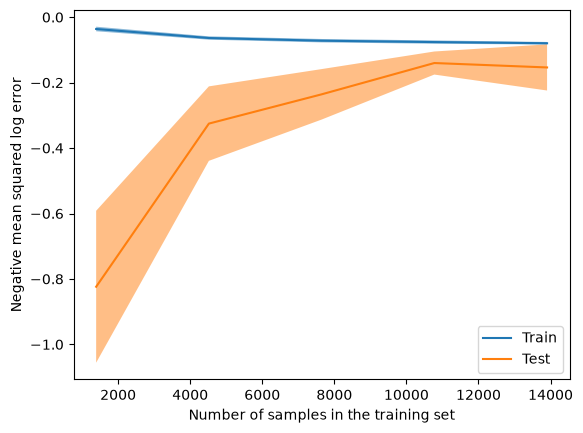

In [64]:
LearningCurveDisplay.from_estimator(
    XGBmodel_tuned, 
    X_eng, 
    y_base,
    cv=5, 
    scoring='neg_mean_squared_log_error'
)
plt.show()

The model seems to hava high variance as the model does noticably better on the training data.

<BarContainer object of 20 artists>

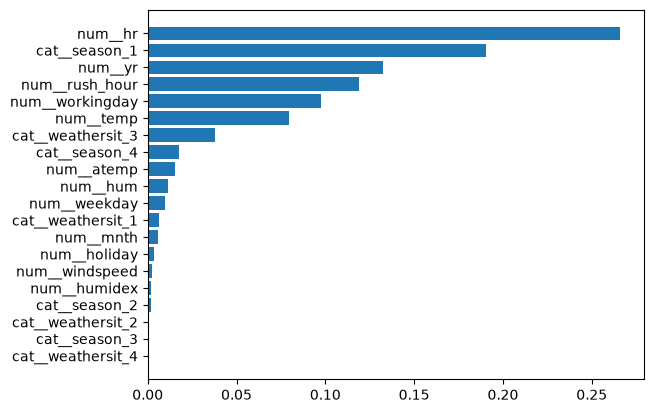

In [65]:
XGBmodel_tuned.fit(X_eng, y_base)
feature_names = XGBmodel_tuned['preprocessor'].get_feature_names_out()
feature_importance = (pd.DataFrame({"Features": feature_names,"Importance_Score": XGBmodel_tuned['model'].regressor_.feature_importances_}).sort_values("Importance_Score", ascending=True))
plt.barh(feature_importance['Features'], feature_importance['Importance_Score'])

0.14214663803577424


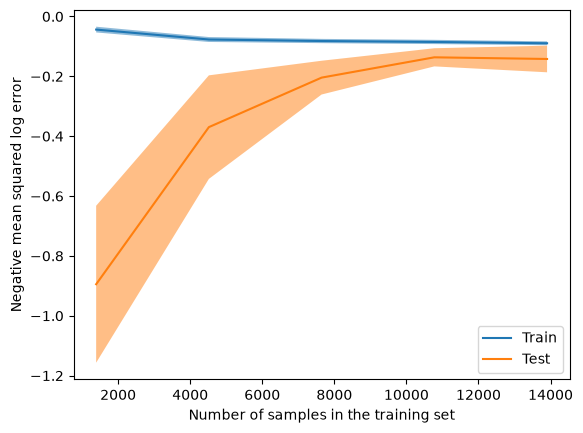

In [67]:
num_cols3 = ['yr', 'hr', 'weekday', 'workingday', 'temp', 'atemp', 'hum', 'rush_hour']

preprocessor3 = ColumnTransformer(transformers=[
    ('num', num_pipe, num_cols3),
    ('cat', obj_pipe, cat_cols)],
    remainder='drop')

XGBmodel_less_features  = Pipeline(steps=[('preprocessor', preprocessor3),
                          ('model', TransformedTargetRegressor(regressor= XGBRegressor(n_estimators=200, max_depth = 3, random_state=42),func=np.log1p, inverse_func=np.expm1))])
XGBmodel_less_features_CV = -1*(cross_val_score(XGBmodel_less_features, X_eng, y_base, cv=5, scoring='neg_mean_squared_log_error').mean())
print(XGBmodel_less_features_CV)

LearningCurveDisplay.from_estimator(
    XGBmodel_less_features, 
    X_eng, 
    y_base,
    cv=5, 
    scoring='neg_mean_squared_log_error'
)
plt.show()

In order to reduce variance I tried increasing gamma, reducing complexity, and removing the least important features. Removing unimportant features was the only strategy that improved the model, but it actually had a pretty significant impact. There is still room for improvement, but the model definitely has less variance.

In [71]:
from datetime import datetime
from workalendar.usa import UnitedStates

df_test = pd.read_csv(r"C:\Users\talon\Downloads\BikeSharing_Test.csv")
def get_hour(datetime):
    return int(datetime[11:13])

def get_month(date, day=False):
    if(day):
        month = date[8:10]
    else:
        month = date[5:7]
    if(month[0] == '0'):
        return int(month[1])
    else:
        return int(month)
    
def get_season(date):
    month = get_month(date)
    day = get_month(date, day=True)
    month_day = month+day/100
    if(month_day<3.21):
        return 1
    elif(month_day<6.21):
        return 2
    elif(month_day<9.23):
        return 3
    else:
        return 4

def get_year(date):
    return int(date[:4])-2011

def get_weekday(date):
    dt = datetime.strptime(date[:10], "%Y-%m-%d")
    return int(dt.weekday() < 5)

cal = UnitedStates()
def get_workingday(date):
    dt = datetime.strptime(date[:10], "%Y-%m-%d")
    return int(cal.is_working_day(dt))

df_test['hr'] = df_test.datetime.apply(get_hour)
df_test['yr'] = df_test.datetime.apply(get_year)
df_test['season'] = df_test.datetime.apply(get_season)
df_test['weekday'] = df_test.datetime.apply(get_weekday)
df_test['workingday'] = df_test.datetime.apply(get_workingday)

df_test = df_test.rename(columns={"weather": "weathersit", "humidity": "hum"})
df_test['hum'] = (df_test['hum']/100).apply(correct_hum)
df_test['temp'] = ((df_test['temp'])/41)
df_test['atemp'] = ((df_test['atemp'])/50)
df_test['rush_hour'] = df_test['hr'].isin([7,8,17,18]).astype(int)

XGBmodel_less_features.fit(X_eng, y_base)
submission_predictions = XGBmodel_less_features.predict(df_test)
submission_pd = pd.DataFrame(df_test['datetime'])
submission_pd['count'] = submission_predictions
submission_pd.to_csv("bike_submission.csv", index=False)

